<a href="https://colab.research.google.com/github/jovian-parco/SBIN/blob/main/SBIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dropout, Flatten, Dense
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PATH="/content/drive/My Drive/SBIN/dataset-resized/dataset-resized"

In [ ]:
train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

In [ ]:
batch_size = 512
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

In [ ]:
train_image_generator = ImageDataGenerator(rescale=1./255) 
validation_image_generator = ImageDataGenerator(rescale=1./255) 

In [ ]:
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                           directory=train_dir,
                                                           shuffle=True,
                                                           target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                           class_mode='categorical')

Found 9554 images belonging to 7 classes.


In [ ]:
val_data_gen = validation_image_generator.flow_from_directory(batch_size=batch_size,
                                                              directory=validation_dir,
                                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                              class_mode='categorical')

Found 688 images belonging to 7 classes.


In [ ]:
base_model = tf.keras.applications.InceptionV3(include_top=False,
    weights="imagenet",
    input_shape=(150, 150, 3))
base_model.trainable = False
X = base_model.output
X = Flatten(input_shape=base_model.output_shape[1:])(X)
X = Dense(256, activation='relu')(X)
X = Dropout(0.5)(X)
Output = Dense(7, activation='softmax')(X)
inception= Model(inputs=base_model.input, outputs=Output)

inception.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
          optimizer=optimizers.Adam(learning_rate = 0.001),
          metrics=['accuracy'])

history = inception.fit(  
    train_data_gen,
    epochs=epochs,
    validation_data = val_data_gen)

Epoch 1/15
19/19 [==============================] - 1990s 103s/step - loss: 8.7651 - accuracy: 0.3623 - val_loss: 1.3731 - val_accuracy: 0.5015
Epoch 2/15
19/19 [==============================] - 36s 2s/step - loss: 1.3386 - accuracy: 0.5243 - val_loss: 1.2828 - val_accuracy: 0.6119
Epoch 3/15
19/19 [==============================] - 36s 2s/step - loss: 1.2045 - accuracy: 0.5971 - val_loss: 1.1485 - val_accuracy: 0.6119
Epoch 4/15
19/19 [==============================] - 36s 2s/step - loss: 1.0789 - accuracy: 0.6318 - val_loss: 1.0093 - val_accuracy: 0.6439
Epoch 5/15
19/19 [==============================] - 37s 2s/step - loss: 0.9988 - accuracy: 0.6534 - val_loss: 0.8496 - val_accuracy: 0.6890
Epoch 6/15
19/19 [==============================] - 36s 2s/step - loss: 0.9043 - accuracy: 0.6910 - val_loss: 0.7348 - val_accuracy: 0.7471
Epoch 7/15
19/19 [==============================] - 41s 2s/step - loss: 0.8324 - accuracy: 0.7084 - val_loss: 0.6906 - val_accuracy: 0.7805
Epoch 8/15
19/19

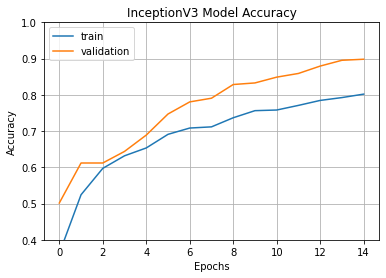

<Figure size 432x288 with 0 Axes>

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('InceptionV3 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
plt.savefig('InceptionV3 Model Accuracy.png', bbox_inches='tight')

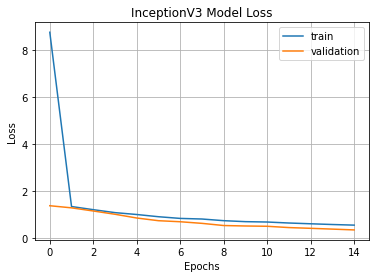

<Figure size 432x288 with 0 Axes>

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('InceptionV3 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
plt.savefig('InceptionV3 Model Loss.png', bbox_inches='tight')

In [ ]:
base_model = tf.keras.applications.xception.Xception(include_top=False,
    weights="imagenet",
    input_shape=(150, 150, 3))
base_model.trainable = False
X = base_model.output
X = Flatten(input_shape=base_model.output_shape[1:])(X)
X = Dense(256, activation='relu')(X)
X = Dropout(0.5)(X)
Output = Dense(7, activation='softmax')(X)
xception= Model(inputs=base_model.input, outputs=Output)

xception.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
          optimizer=optimizers.Adam(learning_rate = 0.001),
          metrics=['accuracy'])

history = xception.fit(  
    train_data_gen,
    epochs=epochs,
    validation_data = val_data_gen)


83683744/83683744 [==============================] - 0s 0us/step
Epoch 1/15
19/19 [==============================] - 54s 2s/step - loss: 4.1908 - accuracy: 0.5252 - val_loss: 0.9541 - val_accuracy: 0.6904
Epoch 2/15
19/19 [==============================] - 38s 2s/step - loss: 0.9522 - accuracy: 0.6764 - val_loss: 0.7088 - val_accuracy: 0.7456
Epoch 3/15
19/19 [==============================] - 38s 2s/step - loss: 0.7863 - accuracy: 0.7344 - val_loss: 0.5642 - val_accuracy: 0.7994
Epoch 4/15
19/19 [==============================] - 38s 2s/step - loss: 0.6733 - accuracy: 0.7692 - val_loss: 0.4900 - val_accuracy: 0.8285
Epoch 5/15
19/19 [==============================] - 39s 2s/step - loss: 0.5928 - accuracy: 0.7860 - val_loss: 0.3926 - val_accuracy: 0.8517
Epoch 6/15
19/19 [==============================] - 38s 2s/step - loss: 0.5242 - accuracy: 0.8109 - val_loss: 0.3645 - val_accuracy: 0.8765
Epoch 7/15
19/19 [==============================] - 38s 2s/step - loss: 0.4749 - accuracy: 0.83

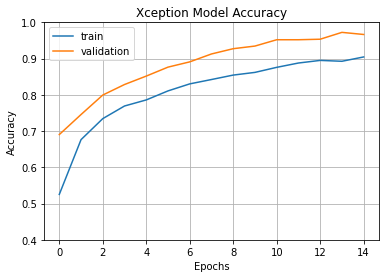

<Figure size 432x288 with 0 Axes>

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Xception Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
plt.savefig('Xception Model Accuracy.png', bbox_inches='tight')

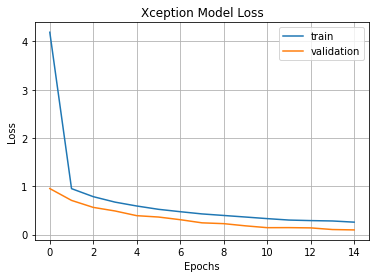

<Figure size 432x288 with 0 Axes>

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Xception Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
plt.savefig('Xception Model Loss.png', bbox_inches='tight')

In [ ]:
 base_model = tf.keras.applications.ResNet50V2(include_top=False,
    weights="imagenet",
    input_shape=(150, 150, 3))
 
base_model.trainable = False

X = base_model.output
X = Flatten(input_shape=base_model.output_shape[1:])(X)
X = Dense(256, activation='relu')(X)
X = Dropout(0.5)(X)
Output = Dense(7, activation='softmax')(X)
resnet= Model(inputs=base_model.input, outputs=Output)

resnet.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
          optimizer=optimizers.Adam(learning_rate = 0.001),
          metrics=['accuracy'])

history = resnet.fit(
    train_data_gen,
    epochs=epochs,
    validation_data = val_data_gen)


94668760/94668760 [==============================] - 1s 0us/step
Epoch 1/15
19/19 [==============================] - 55s 2s/step - loss: 3.8512 - accuracy: 0.5389 - val_loss: 0.7995 - val_accuracy: 0.7529
Epoch 2/15
19/19 [==============================] - 37s 2s/step - loss: 0.8970 - accuracy: 0.6848 - val_loss: 0.6464 - val_accuracy: 0.7718
Epoch 3/15
19/19 [==============================] - 37s 2s/step - loss: 0.7002 - accuracy: 0.7495 - val_loss: 0.4437 - val_accuracy: 0.8416
Epoch 4/15
19/19 [==============================] - 37s 2s/step - loss: 0.5746 - accuracy: 0.7890 - val_loss: 0.3550 - val_accuracy: 0.8663
Epoch 5/15
19/19 [==============================] - 38s 2s/step - loss: 0.4894 - accuracy: 0.8200 - val_loss: 0.3103 - val_accuracy: 0.8837
Epoch 6/15
19/19 [==============================] - 37s 2s/step - loss: 0.4101 - accuracy: 0.8482 - val_loss: 0.2261 - val_accuracy: 0.9288
Epoch 7/15
19/19 [==============================] - 37s 2s/step - loss: 0.3608 - accuracy: 0.86

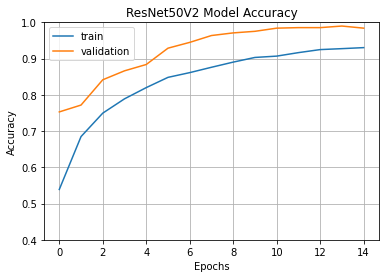

<Figure size 432x288 with 0 Axes>

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('ResNet50V2 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
plt.savefig('ResNet50V2 Model Accuracy.png', bbox_inches='tight')

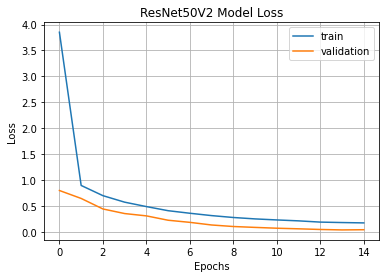

<Figure size 432x288 with 0 Axes>

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('ResNet50V2 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
plt.savefig('ResNet50V2 Model Loss.png', bbox_inches='tight')

In [ ]:
base_model = tf.keras.applications.VGG16(include_top=False,
  weights="imagenet",
  input_shape=(150, 150, 3))
base_model.trainable = False
X = base_model.output
X = Flatten(input_shape=base_model.output_shape[1:])(X)
X = Dense(256, activation='relu')(X)
X = Dropout(0.5)(X)
Output = Dense(7, activation='softmax')(X)
VGG16= Model(inputs=base_model.input, outputs=Output)

VGG16.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
          optimizer=optimizers.Adam(learning_rate = 0.001),
          metrics=['accuracy'])

history = VGG16.fit(
    train_data_gen,
    epochs=epochs,
    validation_data = val_data_gen)

58889256/58889256 [==============================] - 0s 0us/step
Epoch 1/15
19/19 [==============================] - 82s 3s/step - loss: 1.6944 - accuracy: 0.4426 - val_loss: 1.1777 - val_accuracy: 0.5785
Epoch 2/15
19/19 [==============================] - 41s 2s/step - loss: 1.0238 - accuracy: 0.6343 - val_loss: 0.9818 - val_accuracy: 0.6584
Epoch 3/15
19/19 [==============================] - 41s 2s/step - loss: 0.8668 - accuracy: 0.6965 - val_loss: 0.8070 - val_accuracy: 0.7180
Epoch 4/15
19/19 [==============================] - 41s 2s/step - loss: 0.7729 - accuracy: 0.7269 - val_loss: 0.7248 - val_accuracy: 0.7544
Epoch 5/15
19/19 [==============================] - 40s 2s/step - loss: 0.6847 - accuracy: 0.7663 - val_loss: 0.6455 - val_accuracy: 0.7951
Epoch 6/15
19/19 [==============================] - 40s 2s/step - loss: 0.6231 - accuracy: 0.7867 - val_loss: 0.5753 - val_accuracy: 0.8198
Epoch 7/15
19/19 [==============================] - 41s 2s/step - loss: 0.5696 - accuracy: 0.80

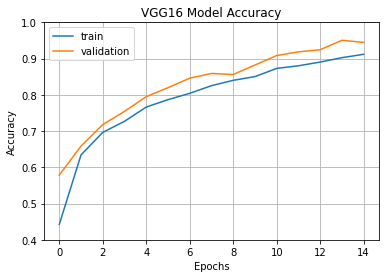

<Figure size 432x288 with 0 Axes>

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('VGG16 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
plt.savefig('VGG16 Model Accuracy.png', bbox_inches='tight')

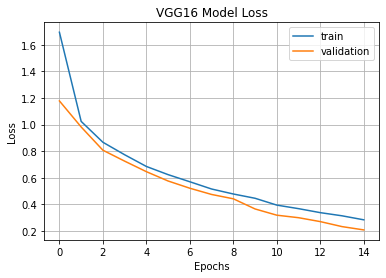

<Figure size 432x288 with 0 Axes>

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('VGG16 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
plt.savefig('VGG16 Model Loss.png', bbox_inches='tight')

In [ ]:
print(val_data_gen.class_indices)

In [ ]:
import cv2
def use_model(path):

    pic = plt.imread(path)
    pic = cv2.resize(pic, (IMG_WIDTH, IMG_HEIGHT))/255
    pic = np.expand_dims(pic, axis=0)
    classes = VGG16.predict(pic)
    shit =np.argmax(classes, axis=1)
    return shit

use_model("/content/drive/MyDrive/SBIN/paper2.jpg")

1/1 [==============================] - 0s 16ms/step


array([4])

In [ ]:
inception.save("inception.h5")
resnet.save("resnet.h5")
VGG16.save("VGG16.h5")
xception.save("xception.h5")

In [ ]:
import time
inception_time=[]
for img in val_data_gen[0][0]:
  img=img/255
  img=np.expand_dims(img,axis=0)
  start_time=time.time()
  inception.predict(img)
  inception_time.append(time.time()-start_time)

resnet_time=[]
for img in val_data_gen[0][0]:
  img=img/255
  img=np.expand_dims(img,axis=0)
  start_time=time.time()
  resnet.predict(img)
  resnet_time.append(time.time()-start_time)

VGG16_time=[]
for img in val_data_gen[0][0]:
  img=img/255
  img=np.expand_dims(img,axis=0)
  start_time=time.time()
  VGG16.predict(img)
  VGG16_time.append(time.time()-start_time)


xception_time=[]
for img in val_data_gen[0][0]:
  img=img/255
  img=np.expand_dims(img,axis=0)
  start_time=time.time()
  xception.predict(img)
  xception_time.append(time.time()-start_time)

1/1 [==============================] - 0s 18ms/step


In [ ]:
del inception_time[79:]
del resnet_time[79:]
del VGG16_time[79:]
del xception_time[79:]

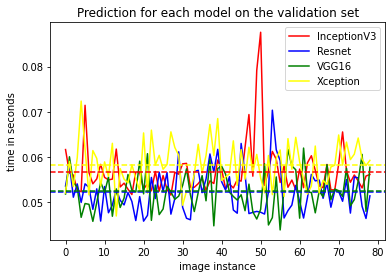

<Figure size 432x288 with 0 Axes>

In [ ]:
plt.plot(inception_time,color='red')
plt.plot(resnet_time,color='blue')
plt.plot(VGG16_time,color='green')
plt.plot(xception_time,color='yellow')
plt.title("Prediction for each model on the validation set")
plt.ylabel('time in seconds')
plt.xlabel('image instance')
plt.legend(['InceptionV3', 'Resnet', 'VGG16','Xception'])
plt.axhline(y=np.nanmean(inception_time),linestyle='--',color='red')
plt.axhline(y=np.nanmean(resnet_time),linestyle='--',color='blue')
plt.axhline(y=np.nanmean(VGG16_time),linestyle='--',color='green')
plt.axhline(y=np.nanmean(xception_time),linestyle='--',color='yellow')
plt.show()
plt.savefig('Prediction for each model on the validation set.png')

In [ ]:
import classify
import base64
import argparse
import operator
import warnings
import RPi.GPIO as GPIO          
import time                      
from picamera import PiCamera
camera = PiCamera() 

warnings.filterwarnings("ignore")

         


while True:
 GPIO.setmode(GPIO.BOARD)
#button
 but=12
 GPIO.setup(but, GPIO.IN, pull_up_down=GPIO.PUD_UP) 
 try:
    i=0 
    while i==0:
       input_state = GPIO.input(but) 
       if input_state == False:     
           print('Button Pressed')   
           time.sleep(0.3)           
        
        #ir sensore
           sensor = 16
           GPIO.setup(sensor,GPIO.IN)
           print ("IR Sensor Ready.....")
           print (" ")

           while i==0:
                if GPIO.input(sensor):
                    print ("Object Detected")

                    
                    camera.start_preview()
                    time.sleep(5)
                    camera.capture('/home/pi/Desktop/image.jpg')
                    camera.stop_preview()
        

                    imagePath = '/home/pi/Desktop/image.jpg'
                    #servo
                    
                    
                    result = classify.analyse(imagePath)
                    val=max(result.items(), key=operator.itemgetter(1))[0]
                    
                    if val=='paper' or val=='carboard' or val=='bio':
                        servo = 11
                        GPIO.setup(servo, GPIO.OUT)
                        p=GPIO.PWM(servo,50)
                        p.start(7.5)
                    
                        print(1)
                        time.sleep(1)
                        p.ChangeDutyCycle(10.5)
                        time.sleep(5)
                        p.ChangeDutyCycle(7.5)
                        time.sleep(1)
                        i=1
                    
                    else:
                        servo = 11
                        GPIO.setup(servo, GPIO.OUT)
                        p=GPIO.PWM(servo,50)
                        p.start(7.5)
                    
                        print(0) 
                        time.sleep(1)
                        p.ChangeDutyCycle(4.5)
                        time.sleep(5)
                        p.ChangeDutyCycle(7.5)
                        time.sleep(1)
                        i=1


 except KeyboardInterrupt:
    GPIO.cleanup()
 GPIO.cleanup()
 print('press button for new detection')